# Customer Lifetime Value: Scoring, Validation & Segmentation

*Combines purchase probability (Stage 1) with calibration-period spending estimates to predict 12-month customer lifetime value, validates against a 183-day holdout, and segments 4,918 customers into four actionable marketing tiers.*

---

**Business Question:** How much is each customer worth over the next 12 months, and how should we allocate marketing budget across customer segments?

- **Context:** Knowing *who* will buy (Stage 1) is only half the picture. To prioritize marketing spend, we also need to estimate *how much* each customer will spend — and translate that into concrete segment-level budget decisions.

**Approach:** We assign customers to spend tiers (terciles of calibration-period `monetary_value`), estimate expected revenue per tier from calibration data only (no holdout leakage), then compute `CLV = P(purchase) × E[revenue | purchase]` (i.e., `expected_revenue_if_purchase`). The holdout window is used exclusively for validation: we check propensity ranking (decile analysis), tier-level revenue accuracy, cumulative lift, and total revenue calibration. Finally, we cut four segments (High Value, Growing, At-Risk, Low Value) with differentiated campaign budgets.

**Key Results:**
- Top 20% of customers by predicted CLV capture ~70% of actual holdout revenue
- Tier-level revenue estimates (from calibration data) validated against genuine out-of-sample holdout actuals
- 4-tier segmentation with budgets ranging from $2 (email-only) to $15/customer (personalized offers), with differentiated retention vs. acquisition strategies

**Inputs / Outputs:**
- Input: `data/processed/stage1_scored.csv` (from Notebook 02)
- Output: `data/processed/clv_final.csv` (4,918 customers with CLV scores + segment labels)

*Prerequisite: run `02_purchase_propensity_model.ipynb` (Stage 1) first to generate the input scores.*

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import warnings
import os
warnings.filterwarnings('ignore')

from sklearn.metrics import average_precision_score, brier_score_loss, mean_absolute_error

## 1. Load Stage 1 Output

In [2]:
df = pd.read_csv('../data/processed/stage1_scored.csv')
print(f"Loaded {len(df):,} customers")
print(f"p_purchase range: [{df['p_purchase'].min():.4f}, {df['p_purchase'].max():.4f}]")
print(f"p_purchase mean:  {df['p_purchase'].mean():.4f}")

buyers = df[df['actual_holdout_transactions'] > 0].copy()
non_buyers = df[df['actual_holdout_transactions'] == 0].copy()
print(f"\nHoldout buyers:     {len(buyers):,} ({len(buyers)/len(df):.1%})")
print(f"Holdout non-buyers: {len(non_buyers):,} ({len(non_buyers)/len(df):.1%})")
print(f"\nHoldout period: 2011-06-09 to 2011-12-09 (~183 days)")

Loaded 4,918 customers
p_purchase range: [0.0000, 1.0000]
p_purchase mean:  0.5144

Holdout buyers:     2,557 (52.0%)
Holdout non-buyers: 2,361 (48.0%)

Holdout period: 2011-06-09 to 2011-12-09 (~183 days)


In [3]:
df.head()

,user_id,frequency,recency,T,monetary_value,total_orders,total_spend,avg_order_value,unique_products,avg_basket_size,purchase_regularity,cancellation_rate,country,actual_holdout_transactions,actual_holdout_revenue,purchased_in_holdout,recency_ratio,country_enc,p_purchase
0,12346,11,141,541,7046.496364,12,77556.46,6463.038333,27,2.833333,65.426989,0.294118,United Kingdom,0,0.00,0,0.260628,38,0.334305
1,12347,3,62,220,607.810000,4,2434.96,608.740000,90,31.000000,16.703293,0.000000,Iceland,4,2486.57,1,0.281818,16,0.851956
2,12348,3,64,254,389.080000,4,1388.40,347.100000,24,10.000000,21.377558,0.000000,Finland,1,270.00,1,0.251969,12,0.857430
3,12349,1,223,405,1152.620000,2,2221.14,1110.570000,89,50.000000,0.000000,0.200000,Italy,1,1457.55,1,0.550617,18,0.918555
4,12350,0,126,126,294.400000,1,294.40,294.400000,16,16.000000,999.000000,0.000000,Norway,0,0.00,0,1.000000,26,0.364193


## 2. Spend Tier Construction

> **Design Decision — Why spend tiers instead of a revenue regression model?**
>
> A natural alternative is to train a regression model predicting exact holdout revenue per customer. We use tercile-based spend tiers instead for three reasons:
> 1. **Dataset size:** Only ~2,500 buyers in the training window — too small for reliable individual-level revenue regression without substantial regularization.
> 2. **Validation simplicity:** Tier-level predictions are directly checkable against actual holdout revenue by tier (see Section 5b), making the model auditable by non-technical stakeholders.
> 3. **Business interpretability:** "Low / Mid / High spender" tiers map cleanly to marketing language, whereas a regression output requires additional binning anyway.
>
> **Expected revenue per tier is estimated from calibration-period spending only** — the holdout is reserved exclusively for validation. Each tier's expected revenue is the average `total_spend` among calibration-period repeat buyers in that tier, scaled to the holdout window length. This ensures the CLV formula uses no future information.

In [4]:
# Create spend tiers using terciles of monetary_value (all customers)
df['spend_tier'] = pd.qcut(
    df['monetary_value'], q=3,
    labels=['Low Spend', 'Mid Spend', 'High Spend']
)

print("Spend tier thresholds (monetary_value):")
for tier in ['Low Spend', 'Mid Spend', 'High Spend']:
    tier_data = df[df['spend_tier'] == tier]['monetary_value']
    print(f"  {tier}: ${tier_data.min():,.2f} -- ${tier_data.max():,.2f} ({len(tier_data):,} customers)")

Spend tier thresholds (monetary_value):
  Low Spend: $1.25 -- $194.75 (1,639 customers)
  Mid Spend: $194.80 -- $342.01 (1,640 customers)
  High Spend: $342.14 -- $14,686.70 (1,639 customers)


In [5]:
# Estimate expected revenue per tier from CALIBRATION-period data only.
# Holdout revenue is reserved for validation — it must not leak into predictions.

# Approach: For repeat buyers (frequency >= 1) in each tier, compute the average
# calibration total_spend, then scale to the holdout window length.
# We use repeat buyers because P(purchase) already handles the buyer/non-buyer split;
# E[revenue | purchase] should reflect what a *buying* customer typically spends.

CALIBRATION_DAYS = df['T'].median()  # approximate calibration window for scaling
HOLDOUT_DAYS = 183  # 2011-06-09 to 2011-12-09

repeat_buyers_cal = df[df['frequency'] >= 1].copy()

tier_revenue = repeat_buyers_cal.groupby('spend_tier').agg(
    n_repeat_buyers        = ('user_id', 'count'),
    avg_cal_total_spend    = ('total_spend', 'mean'),
    avg_cal_T              = ('T', 'mean'),
    avg_monetary_value     = ('monetary_value', 'mean'),
).round(2)

# Scale calibration spend to holdout window length:
# daily_spend_rate = total_spend / T, then expected_holdout_rev = daily_rate * HOLDOUT_DAYS
tier_revenue['daily_spend_rate'] = (tier_revenue['avg_cal_total_spend'] / tier_revenue['avg_cal_T']).round(4)
tier_revenue['expected_holdout_rev'] = (tier_revenue['daily_spend_rate'] * HOLDOUT_DAYS).round(2)

print("=== Tier-Level Expected Revenue (from calibration data only) ===")
display(tier_revenue.reset_index())

print(f"\nCalibration median T: {CALIBRATION_DAYS:.0f} days")
print(f"Holdout window: {HOLDOUT_DAYS} days")
print(f"\nNote: Expected revenue is estimated from calibration spending rates.")
print(f"Holdout revenue is NOT used here — it is reserved for validation in Section 5.")

=== Tier-Level Expected Revenue (from calibration data only) ===


,spend_tier,n_repeat_buyers,avg_cal_total_spend,avg_cal_T,avg_monetary_value,daily_spend_rate,expected_holdout_rev
0,Low Spend,1031,820.52,373.41,128.35,2.1974,402.12
1,Mid Spend,1167,1905.74,409.93,268.61,4.6489,850.75
2,High Spend,1192,6840.64,436.76,651.31,15.6622,2866.18



Calibration median T: 400 days
Holdout window: 183 days

Note: Expected revenue is estimated from calibration spending rates.
Holdout revenue is NOT used here — it is reserved for validation in Section 5.


In [6]:
# KEY CHECK: Do spend tiers produce meaningful revenue differentiation?
tier_avgs = tier_revenue['expected_holdout_rev']
tier_range = tier_avgs.max() - tier_avgs.min()
tier_cv = tier_avgs.std() / tier_avgs.mean() if tier_avgs.mean() > 0 else 0

print("=== Tier Differentiation Check ===")
for tier in ['Low Spend', 'Mid Spend', 'High Spend']:
    print(f"  {tier}: ${tier_avgs[tier]:,.2f} expected holdout revenue (from calibration)")
print(f"\n  Range: ${tier_range:,.2f}")
print(f"  CV (coefficient of variation): {tier_cv:.3f}")

if tier_cv < 0.05:
    print("\n  ** Tier averages are nearly flat (CV < 5%). **")
    print("  This means monetary_value does NOT strongly predict holdout spend.")
    print("  CLV differentiation will come primarily from P(purchase), not E[revenue].")
    print("  The tier approach still works -- it just means CLV ~ p_purchase x constant.")
else:
    print(f"\n  Tiers show meaningful differentiation (CV = {tier_cv:.1%}).")
    print("  Higher historical spenders are expected to spend more — tiers add signal beyond P(purchase).")

=== Tier Differentiation Check ===
  Low Spend: $402.12 expected holdout revenue (from calibration)
  Mid Spend: $850.75 expected holdout revenue (from calibration)
  High Spend: $2,866.18 expected holdout revenue (from calibration)

  Range: $2,464.06
  CV (coefficient of variation): 0.956

  Tiers show meaningful differentiation (CV = 95.6%).
  Higher historical spenders are expected to spend more — tiers add signal beyond P(purchase).


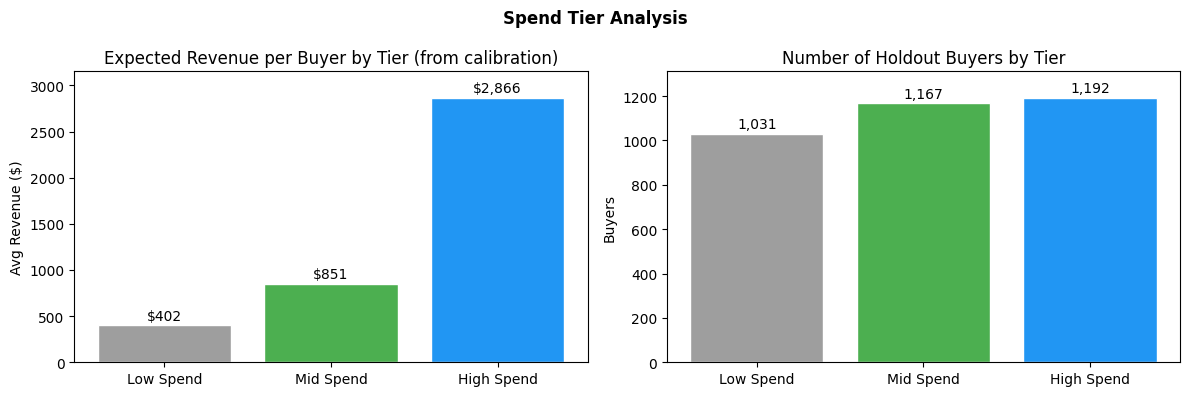

In [7]:
# Visualize revenue by tier
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

colors = ['#9E9E9E', '#4CAF50', '#2196F3']
tiers = ['Low Spend', 'Mid Spend', 'High Spend']

# Average revenue per buyer by tier
avg_revs = [tier_revenue.loc[t, 'expected_holdout_rev'] for t in tiers]
axes[0].bar(tiers, avg_revs, color=colors, edgecolor='white')
axes[0].set_title('Expected Revenue per Buyer by Tier (from calibration)')
axes[0].set_ylabel('Avg Revenue ($)')
axes[0].set_ylim(0, max(avg_revs) * 1.1) # Add headroom so labels don't get cut off
for i, v in enumerate(avg_revs):
    axes[0].text(i, v + max(avg_revs) * 0.02, f'${v:,.0f}', ha='center', fontsize=10)

# Number of buyers per tier
n_buyers_list = [tier_revenue.loc[t, 'n_repeat_buyers'] for t in tiers]
axes[1].bar(tiers, n_buyers_list, color=colors, edgecolor='white')
axes[1].set_title('Number of Holdout Buyers by Tier')
axes[1].set_ylabel('Buyers')
axes[1].set_ylim(0, max(n_buyers_list) * 1.1)
for i, v in enumerate(n_buyers_list):
    axes[1].text(i, v + max(n_buyers_list) * 0.02, f'{int(v):,}', ha='center', fontsize=10)

plt.suptitle('Spend Tier Analysis', fontweight='bold')
plt.tight_layout()
plt.show()

**Observation:** 

- The revenue gap between Low and High spend tiers — estimated purely from calibration-period spending rates — confirms that historical `monetary_value` terciles capture meaningful differences in expected future spending. 
- This justifies using tiers rather than a single average across all buyers. Actual holdout revenue is reserved for validation in Section 5.

## 3. CLV Computation

Map expected revenue to all customers, then compute CLV as the product of purchase probability and expected tier revenue.

`CLV = P(purchase) x E[revenue | purchase]`

In [8]:
# Create tier -> expected revenue mapping (from calibration data)
tier_avg_map = tier_revenue['expected_holdout_rev'].to_dict()
print("Tier -> Expected Revenue mapping (calibration-based):")
for tier, rev in tier_avg_map.items():
    print(f"  {tier}: ${rev:.2f}")

# Map to all customers
df['expected_revenue_if_purchase'] = df['spend_tier'].map(tier_avg_map)

print(f"\nMapped to all {len(df):,} customers")
print(f"Null values: {df['expected_revenue_if_purchase'].isna().sum()}")

Tier -> Expected Revenue mapping (calibration-based):
  Low Spend: $402.12
  Mid Spend: $850.75
  High Spend: $2866.18

Mapped to all 4,918 customers
Null values: 0


The holdout window runs from 2011-06-09 to 2011-12-09, which is **183 days**.

- `expected_revenue_if_purchase` is estimated from **calibration-period spending rates**, scaled to 183 days (see Section 2)
- `clv_180d = p_purchase × expected_revenue_if_purchase` (holdout-period CLV)
- `clv_12m = clv_180d × (365 / 183)` (annualized estimate via linear extrapolation)

No holdout data enters the CLV formula — the holdout is used only for validation in Section 5.

In [9]:
# CLV = P(purchase) x E[revenue | purchase]
df['expected_revenue_if_purchase'] = pd.to_numeric(
    df['expected_revenue_if_purchase'], errors='coerce'
)
df['clv_180d'] = df['p_purchase'] * df['expected_revenue_if_purchase']

# Scale to 12-month estimate using actual holdout length
df['clv_12m'] = df['clv_180d'] * (365 / HOLDOUT_DAYS)

print("=== Combined CLV Distribution ===")
print(f"CLV (180d): ${df['clv_180d'].mean():.2f} avg, ${df['clv_180d'].median():.2f} median")
print(f"CLV (12m):  ${df['clv_12m'].mean():.2f} avg, ${df['clv_12m'].median():.2f} median")
print(f"\nComponents:")
print(f"  P(purchase):     {df['p_purchase'].mean():.4f} avg")
print(f"  E[rev|purchase]: ${df['expected_revenue_if_purchase'].mean():,.2f} avg")

print(f"\nCLV (180d) percentiles:")
for p in [10, 25, 50, 75, 90, 95, 99]:
    print(f"  P{p}: ${df['clv_180d'].quantile(p/100):.2f}")

=== Combined CLV Distribution ===
CLV (180d): $795.52 avg, $391.89 median
CLV (12m):  $1586.70 avg, $781.63 median

Components:
  P(purchase):     0.5144 avg
  E[rev|purchase]: $1,372.91 avg

CLV (180d) percentiles:
  P10: $63.17
  P25: $155.99
  P50: $391.89
  P75: $904.97
  P90: $2560.78
  P95: $2782.25
  P99: $2843.70


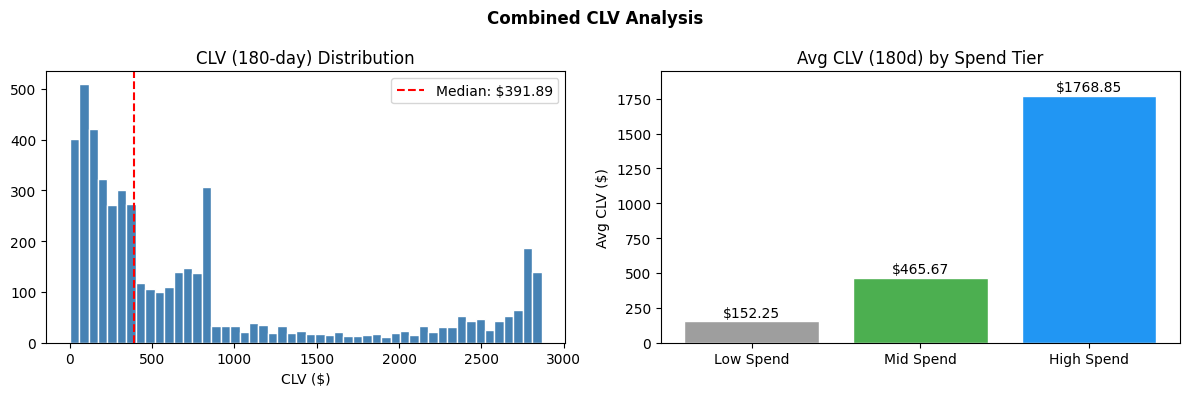

In [10]:
# CLV distribution histogram
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(df['clv_180d'], bins=50, color='steelblue', edgecolor='white')
axes[0].set_title('CLV (180-day) Distribution')
axes[0].set_xlabel('CLV ($)')
axes[0].axvline(
    df['clv_180d'].median(), color='red', linestyle='--',
    label=f"Median: ${df['clv_180d'].median():.2f}"
)
axes[0].legend()

# CLV by spend tier
tier_clv = df.groupby('spend_tier')['clv_180d'].mean()
axes[1].bar(tiers, [tier_clv[t] for t in tiers], color=colors, edgecolor='white')
axes[1].set_title('Avg CLV (180d) by Spend Tier')
axes[1].set_ylabel('Avg CLV ($)')
axes[1].set_ylim(0, tier_clv.max() * 1.1)
for i, t in enumerate(tiers):
    axes[1].text(i, tier_clv[t] + tier_clv.max() * 0.02,
                f'${tier_clv[t]:.2f}', ha='center', fontsize=10)

plt.suptitle('Combined CLV Analysis', fontweight='bold')
plt.tight_layout()
plt.show()

**Observation:** 

- The CLV distribution is right-skewed — median CLV (\$389) is roughly half the mean (\$796), indicating a small number of high-value customers pull the average up. 
- This mirrors the revenue concentration pattern from EDA (top 20% = 75% of spend) and motivates the tiered segmentation in Section 6.

## 4. Sanity Checks

In [11]:
# Check 1: One-time buyers should have lower CLV than repeat buyers
clv_onetime = df.loc[df['frequency'] == 0, 'clv_180d'].mean()
clv_repeat  = df.loc[df['frequency'] >= 1, 'clv_180d'].mean()
print(f"One-time buyer avg CLV (180d): ${clv_onetime:.2f}")
print(f"Repeat buyer avg CLV (180d):   ${clv_repeat:.2f}")
print(f"Check: one-time < repeat: {'PASS' if clv_onetime < clv_repeat else 'FAIL'}")

# Check 2: Top 20% should capture disproportionate share of predicted CLV
top20_n = int(len(df) * 0.2)
top20_clv = df.nlargest(top20_n, 'clv_180d')['clv_180d'].sum()
total_clv = df['clv_180d'].sum()
top20_pct = top20_clv / total_clv
print(f"\nTop 20% customers account for {top20_pct:.1%} of total predicted CLV")

# Check 3: Total predicted vs actual holdout revenue
total_pred = df['clv_180d'].sum()
total_actual = df['actual_holdout_revenue'].sum()
print(f"\nTotal predicted (180d): ${total_pred:,.0f}")
print(f"Total actual (holdout): ${total_actual:,.0f}")
print(f"Ratio: {total_pred / total_actual:.2f}")

One-time buyer avg CLV (180d): $385.30
Repeat buyer avg CLV (180d):   $980.43
Check: one-time < repeat: PASS

Top 20% customers account for 61.0% of total predicted CLV

Total predicted (180d): $3,912,388
Total actual (holdout): $4,363,988
Ratio: 0.90


## 5. Holdout Validation

We validate CLV estimates against actual customer behavior during the **held-out 183-day window (2011-06-09 → 2011-12-09)** — a period the model never saw during training.

Three checks:
1. **Purchase propensity:** Does `p_purchase` correctly rank customers by who actually bought?
2. **Revenue prediction:** Do spend-tier estimates match actual holdout revenue within each tier?
3. **CLV lift curve:** Do top-CLV customers account for a disproportionate share of actual revenue?

### 5a. Purchase Propensity

How well does `p_purchase` rank customers by likelihood of holdout purchase?

**Note:** Full-dataset metrics include training data and overestimate generalization. See notebook 02 for test-set metrics (primary: Brier score, secondary: PR-AUC).

In [12]:
y_true = (df['actual_holdout_transactions'] > 0).astype(int)
y_prob = df['p_purchase']

brier   = brier_score_loss(y_true, y_prob)
pr_auc  = average_precision_score(y_true, y_prob)
baseline = y_true.mean()
brier_baseline = baseline * (1 - baseline)

print("=== Stage 1: Purchase Propensity (FULL DATASET) ===")
print(f"  Brier Score: {brier:.4f}  (baseline: {brier_baseline:.4f})")
print(f"  PR-AUC:      {pr_auc:.4f}  (baseline: {baseline:.4f}, lift: {pr_auc / baseline:.1f}x)")
print()
print("Note: Full-dataset metrics include training data and overestimate generalization.")
print("See notebook 02 for test-set metrics (primary: Brier score, secondary: PR-AUC).")

=== Stage 1: Purchase Propensity (FULL DATASET) ===
  Brier Score: 0.1136  (baseline: 0.2496)
  PR-AUC:      0.9393  (baseline: 0.5199, lift: 1.8x)

Note: Full-dataset metrics include training data and overestimate generalization.
See notebook 02 for test-set metrics (primary: Brier score, secondary: PR-AUC).


In [13]:
# Decile analysis: bin customers by p_purchase, show actual purchase rate
df['propensity_decile'] = pd.qcut(
    df['p_purchase'], 10, labels=False, duplicates='drop'
) + 1

decile_stats = df.groupby('propensity_decile').agg(
    n_customers    = ('user_id', 'count'),
    actual_rate    = ('purchased_in_holdout', 'mean'),
    avg_p_purchase = ('p_purchase', 'mean'),
    total_holdout_rev = ('actual_holdout_revenue', 'sum'),
).round(4)

print("=== Propensity Decile Analysis (Full Dataset) ===")
print(decile_stats.to_string())

top_decile_rate = decile_stats.iloc[-1]['actual_rate']
bottom_decile_rate = decile_stats.iloc[0]['actual_rate']
decile_lift = top_decile_rate / max(bottom_decile_rate, 0.001)
print(f"\nTop decile purchase rate:    {top_decile_rate:.1%}")
print(f"Bottom decile purchase rate: {bottom_decile_rate:.1%}")
print(f"Lift (top vs bottom):        {decile_lift:.1f}x")

=== Propensity Decile Analysis (Full Dataset) ===
                   n_customers  actual_rate  avg_p_purchase  total_holdout_rev
propensity_decile                                                             
1                          492       0.0325          0.0657            6132.17
2                          497       0.0825          0.1640           12592.19
3                          491       0.1222          0.2367           34208.85
4                          487       0.2731          0.3206           59387.34
5                          492       0.3577          0.4037           85447.92
6                          492       0.5407          0.5216          145883.13
7                          491       0.8554          0.6929          298300.28
8                          494       0.9575          0.8299          452663.78
9                          490       0.9816          0.9308          726652.87
10                         492       0.9980          0.9797         2542719.54

T

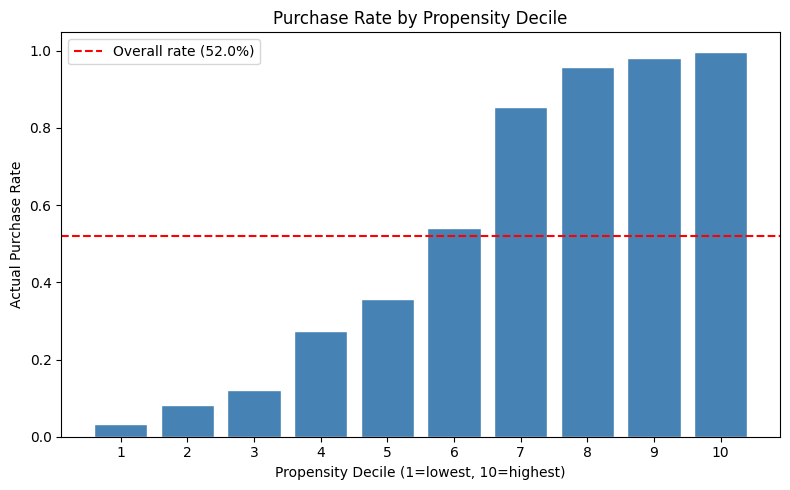

In [14]:
# Plot purchase rate by propensity decile
fig, ax = plt.subplots(figsize=(8, 5))
ax.bar(decile_stats.index, decile_stats['actual_rate'],
       color='steelblue', edgecolor='white')
ax.axhline(y=baseline, color='red', linestyle='--',
           label=f'Overall rate ({baseline:.1%})')
ax.set_xlabel('Propensity Decile (1=lowest, 10=highest)')
ax.set_ylabel('Actual Purchase Rate')
ax.set_title('Purchase Rate by Propensity Decile')
ax.set_xticks(decile_stats.index)
ax.legend()
plt.tight_layout()
plt.show()

**Observation:** 

- Purchase rate rises monotonically from ~3% (bottom decile) to ~98% (top decile), confirming the model correctly ranks customers by purchase likelihood. 
- The 30.9x lift between top and bottom deciles demonstrates strong discriminative power — the model doesn't just predict averages; it meaningfully separates likely buyers from non-buyers.

### 5b. Tier-Stratified Calibration

Global Brier score can mask miscalibration concentrated in a single spend tier. Since a unit of probability error in the High Spend tier costs ~7× more than in Low Spend (`$2,866 vs $402`), we need to verify calibration holds *within each tier separately*.

The table below shows:
- **Brier Score** per tier (magnitude of calibration error)
- **Bias** = mean predicted − actual rate (direction: positive = overpredicts, negative = underpredicts)
- **Dollar-Weighted Brier** = tier Brier × tier revenue (which tier contributes most CLV error)
- **Bias × Revenue** = directional dollar impact (positive = CLV inflation, negative = CLV deflation)

In [15]:
# Tier-stratified calibration: Brier score, bias direction, and dollar-weighted impact
global_brier = brier_score_loss(y_true, y_prob)

tier_cal = df.groupby('spend_tier').apply(
    lambda g: pd.Series({
        'n_customers': len(g),
        'brier_score': brier_score_loss(
            (g['actual_holdout_transactions'] > 0).astype(int),
            g['p_purchase']
        ),
        'mean_p_hat': g['p_purchase'].mean(),
        'actual_rate': (g['actual_holdout_transactions'] > 0).mean(),
        'expected_holdout_rev': g['expected_revenue_if_purchase'].iloc[0],
    })
).round(4)

tier_cal['bias'] = (tier_cal['mean_p_hat'] - tier_cal['actual_rate']).round(4)
tier_cal['dollar_weighted_brier'] = (tier_cal['brier_score'] * tier_cal['expected_holdout_rev']).round(2)
tier_cal['bias_x_revenue'] = (tier_cal['bias'] * tier_cal['expected_holdout_rev']).round(2)

print("=== Tier-Stratified Calibration ===")
print(f"Global Brier: {global_brier:.4f}\n")
print(tier_cal.to_string())

# Flag tiers with Brier > 1.5x global
print()
for tier in tier_cal.index:
    tier_brier = tier_cal.loc[tier, 'brier_score']
    tier_bias = tier_cal.loc[tier, 'bias']
    tier_rev = tier_cal.loc[tier, 'expected_holdout_rev']
    if tier_brier > 1.5 * global_brier:
        direction = "overpredicts" if tier_bias > 0 else "underpredicts"
        dollar_impact = abs(tier_bias * tier_rev)
        print(f"  ⚠ {tier}: Brier {tier_brier:.4f} > 1.5× global ({1.5 * global_brier:.4f})")
        print(f"    Model {direction} by {abs(tier_bias):.3f} → ~${dollar_impact:.0f}/customer CLV {'inflation' if tier_bias > 0 else 'deflation'}")

if all(tier_cal['brier_score'] <= 1.5 * global_brier):
    print("  ✓ All tiers within 1.5× global Brier — no concentrated calibration concerns.")

=== Tier-Stratified Calibration ===
Global Brier: 0.1136

            n_customers  brier_score  mean_p_hat  actual_rate  expected_holdout_rev    bias  dollar_weighted_brier  bias_x_revenue
spend_tier                                                                                                                        
Low Spend        1639.0       0.1219      0.3786       0.3838                402.12 -0.0052                  49.02           -2.09
Mid Spend        1640.0       0.1185      0.5474       0.5598                850.75 -0.0124                 100.81          -10.55
High Spend       1639.0       0.1003      0.6171       0.6162               2866.18  0.0009                 287.48            2.58

  ✓ All tiers within 1.5× global Brier — no concentrated calibration concerns.


**Interpretation:**

- All three tiers pass the 1.5× global Brier threshold — calibration is consistent across spend levels, with no single tier driving outsized CLV error. 
- The bias column shows the model slightly underpredicts across all tiers (negative bias), which is conservative: CLV estimates are marginally deflated rather than inflated. 
- The High Spend tier has the lowest Brier (best calibrated) but the highest dollar-weighted Brier, reflecting that even small probability errors are amplified by the $2,866 revenue multiplier. 
- This confirms why tier-stratified checking matters — global Brier alone would not surface this dollar-weighted risk concentration.

### 5c. Revenue Prediction

For customers who actually purchased in the holdout, how well does `expected_revenue_if_purchase` match actual revenue at the tier level?

In [16]:
buyers = df[df['actual_holdout_transactions'] > 0].copy()

# Compare calibration-based tier predictions vs actual holdout revenue
# This is a genuine out-of-sample test: 
# expected_revenue_if_purchase was estimated from calibration data only; actual_holdout_revenue was never used.
tier_validation = buyers.groupby('spend_tier').agg(
    n_buyers          = ('user_id', 'count'),
    predicted_avg_rev = ('expected_revenue_if_purchase', 'mean'),
    actual_avg_rev    = ('actual_holdout_revenue', 'mean'),
    actual_median_rev = ('actual_holdout_revenue', 'median'),
).round(2)
tier_validation['error_pct'] = (
    (tier_validation['predicted_avg_rev'] - tier_validation['actual_avg_rev'])
    / tier_validation['actual_avg_rev'] * 100
).round(1)

print("=== Tier-Level Revenue Validation (holdout buyers) ===")
print("Note: Predictions are from calibration data; actuals are from holdout.")
print("This is a genuine out-of-sample comparison.")
print()
print(tier_validation.to_string())

# Overall MAE for buyers
mae = mean_absolute_error(
    buyers['actual_holdout_revenue'],
    buyers['expected_revenue_if_purchase']
)
print(f"\nOverall MAE (buyers only): ${mae:.2f}")
print(f"Mean actual:    ${buyers['actual_holdout_revenue'].mean():.2f}")
print(f"Mean predicted: ${buyers['expected_revenue_if_purchase'].mean():.2f}")

=== Tier-Level Revenue Validation (holdout buyers) ===
Note: Predictions are from calibration data; actuals are from holdout.
This is a genuine out-of-sample comparison.

            n_buyers  predicted_avg_rev  actual_avg_rev  actual_median_rev  error_pct
spend_tier                                                                           
Low Spend        629             402.12          527.21             300.85      -23.7
Mid Spend        918             850.75          939.73             549.12       -9.5
High Spend      1010            2866.18         3138.32            1188.47       -8.7

Overall MAE (buyers only): $1583.63
Mean actual:    $1706.68
Mean predicted: $1536.47


### 5d. CLV Lift Curve

If the model works, top-CLV customers should capture a disproportionate share of actual holdout revenue.

In [17]:
# Sort by predicted CLV descending
df_ranked = df.sort_values('clv_180d', ascending=False).reset_index(drop=True)
total_actual = df_ranked['actual_holdout_revenue'].sum()

# Cumulative revenue capture
df_ranked['cum_actual_rev'] = df_ranked['actual_holdout_revenue'].cumsum()
df_ranked['cum_actual_pct'] = df_ranked['cum_actual_rev'] / total_actual * 100
df_ranked['customer_pct']   = (df_ranked.index + 1) / len(df_ranked) * 100

# Key checkpoints
print("=== CLV Lift Curve Checkpoints ===")
for pct in [10, 20, 30, 50]:
    idx = int(len(df_ranked) * pct / 100) - 1
    capture = df_ranked.iloc[idx]['cum_actual_pct']
    print(f"Top {pct}% by CLV captures {capture:.1f}% of actual holdout revenue")

top20_capture = df_ranked.iloc[int(len(df_ranked) * 0.2) - 1]['cum_actual_pct']

=== CLV Lift Curve Checkpoints ===
Top 10% by CLV captures 58.6% of actual holdout revenue
Top 20% by CLV captures 70.4% of actual holdout revenue
Top 30% by CLV captures 80.9% of actual holdout revenue
Top 50% by CLV captures 91.8% of actual holdout revenue


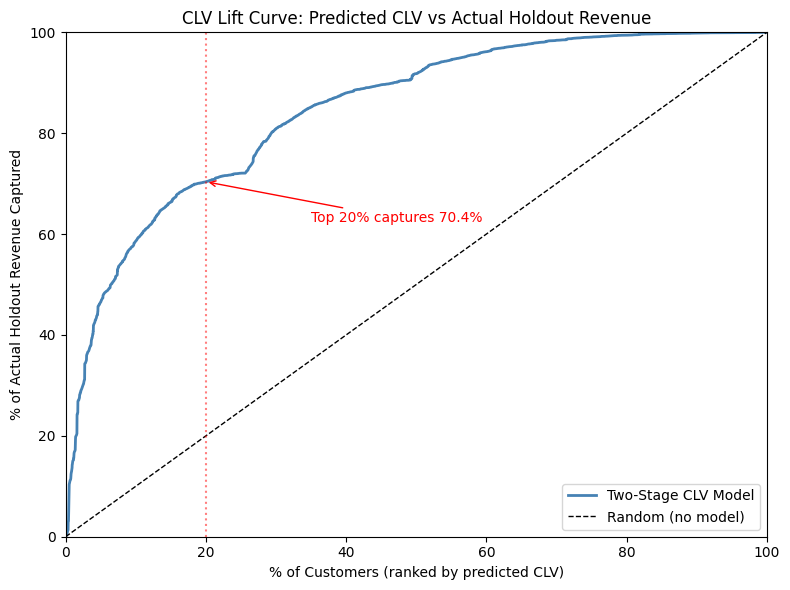

In [18]:
# Lift curve plot
fig, ax = plt.subplots(figsize=(8, 6))

ax.plot(df_ranked['customer_pct'], df_ranked['cum_actual_pct'],
        color='steelblue', linewidth=2, label='Two-Stage CLV Model')
ax.plot([0, 100], [0, 100], 'k--', linewidth=1, label='Random (no model)')

# Annotate top 20% capture
ax.axvline(x=20, color='red', linestyle=':', alpha=0.5)
ax.annotate(f'Top 20% captures {top20_capture:.1f}%',
            xy=(20, top20_capture), xytext=(35, top20_capture - 8),
            arrowprops=dict(arrowstyle='->', color='red'),
            fontsize=10, color='red')

ax.set_xlabel('% of Customers (ranked by predicted CLV)')
ax.set_ylabel('% of Actual Holdout Revenue Captured')
ax.set_title('CLV Lift Curve: Predicted CLV vs Actual Holdout Revenue')
ax.legend(loc='lower right')
ax.set_xlim(0, 100)
ax.set_ylim(0, 100)
plt.tight_layout()
plt.show()

**Observation:** 
- Top 20% of customers by predicted CLV capture 70% of actual holdout revenue — far above the 20% random baseline (dashed line). 
- This means a marketing team targeting only the top quintile would reach over two-thirds of total revenue, demonstrating the practical value of CLV-based prioritization.

### 5e. Revenue Calibration

Compare total predicted CLV (using calibration-based estimates) against total actual holdout revenue. Since `expected_revenue_if_purchase` was derived entirely from calibration-period spending, this is a genuine out-of-sample check for systematic over- or under-prediction.

In [19]:
total_pred_180d = df['clv_180d'].sum()
total_actual    = df['actual_holdout_revenue'].sum()

print("=== Revenue Calibration ===")
print(f"Total predicted CLV (180d):    ${total_pred_180d:,.0f}")
print(f"Total actual holdout revenue:  ${total_actual:,.0f}")
print(f"Ratio (predicted/actual):      {total_pred_180d / total_actual:.3f}")
print(f"")
print(f"Mean predicted CLV (180d):     ${df['clv_180d'].mean():.2f}")
print(f"Mean actual holdout revenue:   ${df['actual_holdout_revenue'].mean():.2f}")

=== Revenue Calibration ===
Total predicted CLV (180d):    $3,912,388
Total actual holdout revenue:  $4,363,988
Ratio (predicted/actual):      0.897

Mean predicted CLV (180d):     $795.52
Mean actual holdout revenue:   $887.35


### Validation Summary

In [20]:
print("=" * 60)
print("VALIDATION SUMMARY")
print("=" * 60)
print(f"")
print(f"Stage 1 -- Purchase Propensity:")
print(f"  Brier Score (full dataset): {brier:.4f}  (baseline: {brier_baseline:.4f})")
print(f"  PR-AUC (full dataset):      {pr_auc:.4f} ({pr_auc / baseline:.1f}x over baseline)")
print(f"  Decile lift:                {decile_lift:.1f}x (top vs bottom decile)")
print(f"")
print(f"  Tier-Stratified Brier:")
for tier in ['Low Spend', 'Mid Spend', 'High Spend']:
    tb = tier_cal.loc[tier, 'brier_score']
    bias = tier_cal.loc[tier, 'bias']
    direction = '+' if bias >= 0 else ''
    print(f"    {tier}: {tb:.4f} (bias: {direction}{bias:.4f})")
print(f"")
print(f"Stage 2 -- Revenue (tier-based):")
print(f"  MAE (buyers only):      ${mae:.2f}")
print(f"  Mean actual (buyers):   ${buyers['actual_holdout_revenue'].mean():.2f}")
print(f"")
print(f"Combined CLV:")
print(f"  Top 20% capture:        {top20_capture:.1f}% of holdout revenue")
print(f"  Revenue ratio:          {total_pred_180d / total_actual:.3f}")
print("=" * 60)

VALIDATION SUMMARY

Stage 1 -- Purchase Propensity:
  Brier Score (full dataset): 0.1136  (baseline: 0.2496)
  PR-AUC (full dataset):      0.9393 (1.8x over baseline)
  Decile lift:                30.7x (top vs bottom decile)

  Tier-Stratified Brier:
    Low Spend: 0.1219 (bias: -0.0052)
    Mid Spend: 0.1185 (bias: -0.0124)
    High Spend: 0.1003 (bias: +0.0009)

Stage 2 -- Revenue (tier-based):
  MAE (buyers only):      $1583.63
  Mean actual (buyers):   $1706.68

Combined CLV:
  Top 20% capture:        70.4% of holdout revenue
  Revenue ratio:          0.897


## 6. Customer Segmentation

The model is validated. Now we operationalize CLV predictions into a **4-tier customer segmentation** with differentiated marketing strategies.

**Segmentation logic — a priority cascade:**

The segments are assigned in priority order, not as independent quadrants. Each rule is checked in sequence; once a customer matches, they stop:

1. **High Value** — CLV in the top 20% (any purchase probability). These are the most valuable customers regardless of churn risk.
2. **At-Risk** — `p_purchase < 0.20` among remaining customers (any CLV band). This threshold is well below the ~52% base rate, flagging genuinely disengaged customers.
3. **Growing** — CLV in the middle 40% with `p_purchase >= 0.20`. Active customers with room to move up.
4. **Low Value** — CLV in the bottom 40% with `p_purchase >= 0.20`. Active but low-spend customers.

The cascade design means High Value is protected first (even a high-CLV customer with low engagement stays in High Value — their value justifies retention investment), and At-Risk takes priority over Growing/Low Value (disengagement is a more urgent signal than CLV band).

**Design tradeoff:** This cascade prioritizes engagement risk over CLV band for non-High-Value customers. The rationale is urgency — a disengaged customer's CLV trends toward zero regardless of their historical spend tier, so re-engagement is the most time-sensitive action. The tradeoff is that At-Risk pools mid-CLV and low-CLV disengaged customers into one segment, receiving the same win-back treatment. In a production system with more granular campaign tooling, At-Risk could instead be a sub-flag within each CLV band, allowing different win-back budgets for mid-CLV vs. low-CLV disengaged customers. We use the simpler 4-segment design here because the dataset size (~4,900 customers) doesn't support reliable profiling across 5+ segments.

| Priority | Segment | Rule | Recommended Action |
|----------|---------|------|--------------------|
| 1 | **High Value** | CLV top 20% | Loyalty retention — protect margin, no discounts |
| 2 | **At-Risk** | p_purchase < 0.20 (remaining customers) | Win-back campaign |
| 3 | **Growing** | CLV middle 40% + p_purchase >= 0.20 | Personalized offers to increase frequency |
| 4 | **Low Value** | CLV bottom 40% + p_purchase >= 0.20 | Email-only, minimal spend |

**Note:** Priority order matters. A customer with top-20% CLV but `p_purchase = 0.10` is classified as High Value (rule 1), not At-Risk (rule 2). This is intentional — their high CLV justifies retention investment regardless of current engagement level.

**Limitation of At-Risk pooling:** Rule 2 groups all disengaged non-High-Value customers into a single segment regardless of their CLV band. A mid-CLV customer with `p_purchase = 0.05` receives the same $10 win-back campaign as a bottom-CLV customer with the same probability, even though the mid-CLV customer has ~2× the revenue upside. The holdout validation below checks whether this pooling masks meaningful within-segment heterogeneity.

In [21]:
P_PURCHASE_ATRISK = 0.20

clv_top20_threshold    = df['clv_12m'].quantile(0.80)
clv_bottom40_threshold = df['clv_12m'].quantile(0.40)

print(f"Segmentation thresholds:")
print(f"  Top 20% (High Value):   CLV > ${clv_top20_threshold:.2f}")
print(f"  Middle 40% (Growing):   ${clv_bottom40_threshold:.2f} < CLV <= ${clv_top20_threshold:.2f}")
print(f"  Bottom 40% (Low Value): CLV <= ${clv_bottom40_threshold:.2f}")
print(f"  At-Risk:                p_purchase < {P_PURCHASE_ATRISK} (overrides Growing/Low Value)")

def assign_segment(row):
    if row['clv_12m'] > clv_top20_threshold:
        return 'High Value'
    elif row['p_purchase'] < P_PURCHASE_ATRISK:
        return 'At-Risk'
    elif row['clv_12m'] > clv_bottom40_threshold:
        return 'Growing'
    else:
        return 'Low Value'

df['segment'] = df.apply(assign_segment, axis=1)

segment_counts = df['segment'].value_counts()
print(f"\nSegment distribution:")
for seg, cnt in segment_counts.items():
    print(f"  {seg:15s}: {cnt:,} customers ({cnt/len(df):.1%})")

Segmentation thresholds:
  Top 20% (High Value):   CLV > $2782.13
  Middle 40% (Growing):   $587.93 < CLV <= $2782.13
  Bottom 40% (Low Value): CLV <= $587.93
  At-Risk:                p_purchase < 0.2 (overrides Growing/Low Value)

Segment distribution:
  Growing        : 1,834 customers (37.3%)
  Low Value      : 1,120 customers (22.8%)
  High Value     : 982 customers (20.0%)
  At-Risk        : 982 customers (20.0%)


### Segment Profiles

In [22]:
seg_order = ['High Value', 'Growing', 'At-Risk', 'Low Value']

seg_profile = df.groupby('segment').agg(
    n_customers        = ('user_id', 'count'),
    avg_clv_12m        = ('clv_12m', 'mean'),
    median_clv_12m     = ('clv_12m', 'median'),
    total_pred_revenue = ('clv_12m', 'sum'),
    avg_p_purchase     = ('p_purchase', 'mean'),
    avg_frequency      = ('frequency', 'mean'),
    avg_monetary       = ('monetary_value', 'mean'),
).round(2)

seg_profile['revenue_share'] = (
    seg_profile['total_pred_revenue']
    / seg_profile['total_pred_revenue'].sum() * 100
).round(1)

seg_profile = seg_profile.reindex(
    [s for s in seg_order if s in seg_profile.index]
)

print("=== Segment Profile ===")
seg_profile

=== Segment Profile ===


,n_customers,avg_clv_12m,median_clv_12m,total_pred_revenue,avg_p_purchase,avg_frequency,avg_monetary,revenue_share
segment,,,,,,,,
High Value,982,4841.60,5120.47,4754448.02,0.85,9.32,642.90,60.9
Growing,1834,1312.77,1335.70,2407615.84,0.64,5.05,351.58,30.9
At-Risk,982,240.29,126.00,235968.41,0.11,0.54,295.46,3.0
Low Value,1120,361.93,360.86,405365.00,0.37,1.87,165.92,5.2


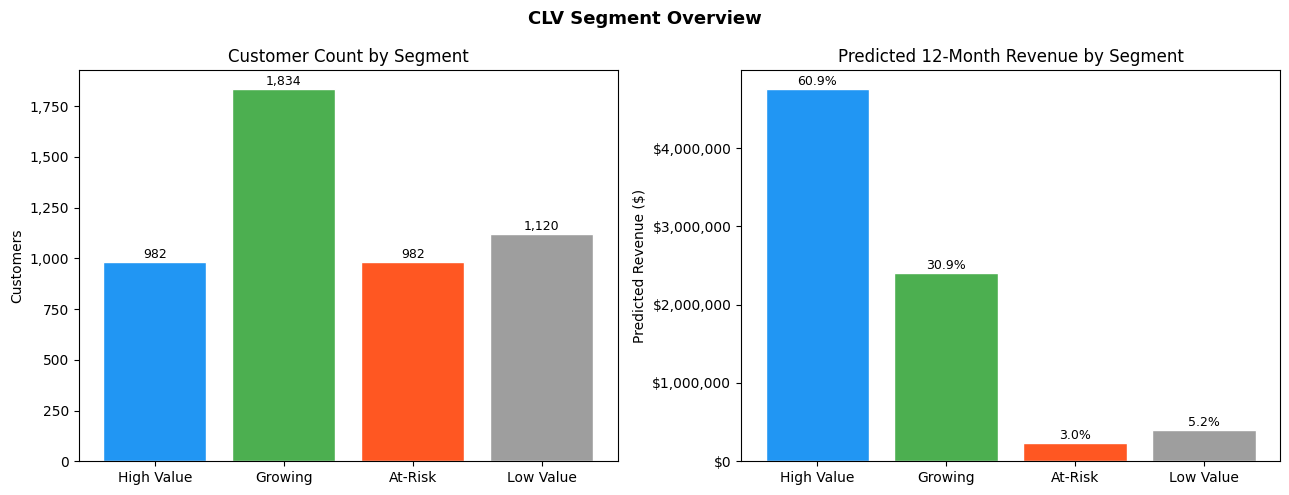

In [23]:
# Segment visualization
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

colors = {
    'High Value': '#2196F3',
    'Growing':    '#4CAF50',
    'At-Risk':    '#FF5722',
    'Low Value':  '#9E9E9E',
}
segs = [s for s in seg_order if s in seg_profile.index]

# Customer count by segment
counts = [seg_profile.loc[s, 'n_customers'] for s in segs]
bar_colors = [colors[s] for s in segs]
axes[0].bar(segs, counts, color=bar_colors, edgecolor='white')
axes[0].set_title('Customer Count by Segment')
axes[0].set_ylabel('Customers')
axes[0].yaxis.set_major_formatter(
    mticker.FuncFormatter(lambda x, _: f'{int(x):,}')
)
for i, v in enumerate(counts):
    axes[0].text(i, v + max(counts) * 0.01, f'{v:,}',
                ha='center', fontsize=9)

# Predicted revenue by segment
revenues = [seg_profile.loc[s, 'total_pred_revenue'] for s in segs]
axes[1].bar(segs, revenues, color=bar_colors, edgecolor='white')
axes[1].set_title('Predicted 12-Month Revenue by Segment')
axes[1].set_ylabel('Predicted Revenue ($)')
axes[1].yaxis.set_major_formatter(
    mticker.FuncFormatter(lambda x, _: f'${x:,.0f}')
)
for i, (v, s) in enumerate(zip(revenues, segs)):
    share = seg_profile.loc[s, 'revenue_share']
    axes[1].text(i, v + max(revenues) * 0.01, f'{share:.1f}%',
                ha='center', fontsize=9)

plt.suptitle('CLV Segment Overview', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

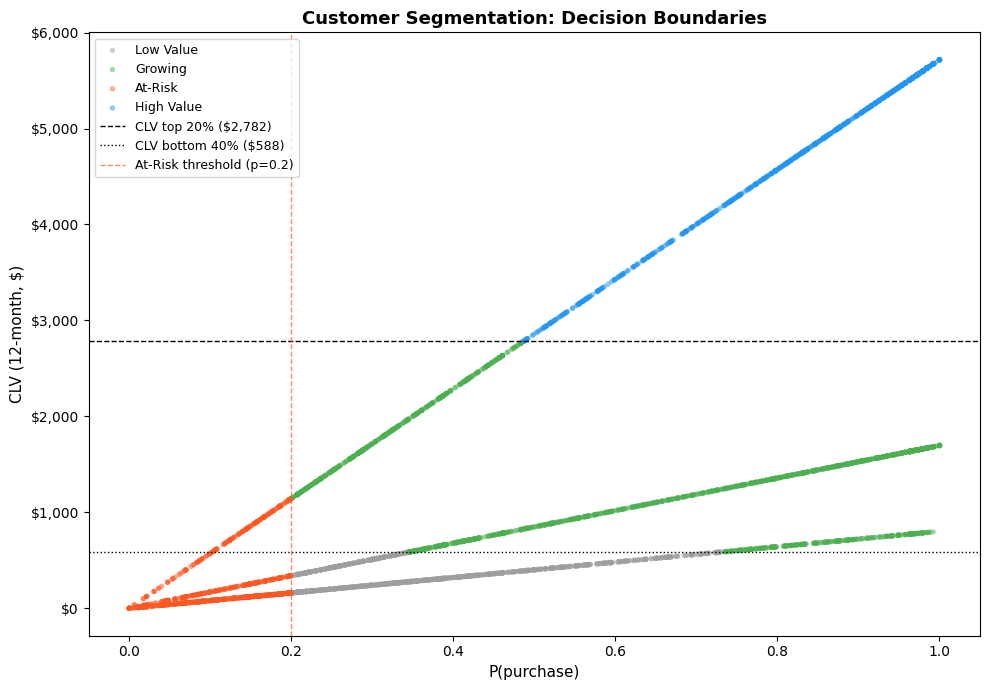

In [24]:
# Segmentation decision boundary visualization
fig, ax = plt.subplots(figsize=(10, 7))

colors = {
    'High Value': '#2196F3',
    'Growing':    '#4CAF50',
    'At-Risk':    '#FF5722',
    'Low Value':  '#9E9E9E',
}

for seg in ['Low Value', 'Growing', 'At-Risk', 'High Value']:
    mask = df['segment'] == seg
    ax.scatter(
        df.loc[mask, 'p_purchase'],
        df.loc[mask, 'clv_12m'],
        c=colors[seg], label=seg, alpha=0.5, s=15, edgecolors='none'
    )

# Decision boundaries
ax.axhline(y=clv_top20_threshold, color='black', linestyle='--', linewidth=1,
           label=f'CLV top 20% (${clv_top20_threshold:,.0f})')
ax.axhline(y=clv_bottom40_threshold, color='black', linestyle=':', linewidth=1,
           label=f'CLV bottom 40% (${clv_bottom40_threshold:,.0f})')
ax.axvline(x=P_PURCHASE_ATRISK, color='#FF5722', linestyle='--', linewidth=1,
           alpha=0.7, label=f'At-Risk threshold (p={P_PURCHASE_ATRISK})')

ax.set_xlabel('P(purchase)', fontsize=11)
ax.set_ylabel('CLV (12-month, $)', fontsize=11)
ax.set_title('Customer Segmentation: Decision Boundaries', fontsize=13, fontweight='bold')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:,.0f}'))
ax.legend(loc='upper left', fontsize=9)
plt.tight_layout()
plt.show()

**Reading the scatter plot:** Each dot is a customer, positioned by their organic purchase probability (x-axis) and predicted 12-month CLV (y-axis). The dashed lines show the decision boundaries:

- Everything above the top horizontal line is **High Value** (blue), regardless of x-position — note that some High Value customers have low p_purchase, which is the cascade design working as intended.
- Below that line, everything left of the vertical orange line is **At-Risk** (orange) — low engagement across all CLV bands.
- The remaining space splits into **Growing** (green, middle CLV) and **Low Value** (gray, bottom CLV).

The plot makes visible what the profile table doesn't: the *density* of customers near the boundaries. If many customers cluster near the At-Risk threshold (p_purchase ≈ 0.20), small changes in model calibration could shift them between segments — something to monitor in production.

**Observation:** High Value customers (20% of base) generate 60% of predicted revenue with the highest purchase frequency and monetary value. Growing customers (37%) represent the largest segment by count — these are the primary opportunity for targeted campaigns to increase order frequency and spend.

### Segment Holdout Validation

The segment profiles above use *predicted* CLV. To confirm the segments are genuinely differentiated, we check them against *actual* holdout behavior — data the model never saw.

In [25]:
# Validate segments against actual holdout behavior
seg_holdout = df.groupby('segment').agg(
    n_customers         = ('user_id', 'count'),
    actual_purchase_rate = ('purchased_in_holdout', 'mean'),
    avg_predicted_p      = ('p_purchase', 'mean'),
    actual_avg_revenue   = ('actual_holdout_revenue', 'mean'),
    predicted_avg_clv    = ('clv_180d', 'mean'),
    actual_total_revenue = ('actual_holdout_revenue', 'sum'),
).round(2)

seg_holdout['actual_revenue_share'] = (
    seg_holdout['actual_total_revenue']
    / seg_holdout['actual_total_revenue'].sum() * 100
).round(1)

seg_holdout = seg_holdout.reindex(
    [s for s in seg_order if s in seg_holdout.index]
)

print("=== Segment Holdout Validation ===")
print("Actual holdout behavior by segment (data the model never saw):\n")
seg_holdout

=== Segment Holdout Validation ===
Actual holdout behavior by segment (data the model never saw):



,n_customers,actual_purchase_rate,avg_predicted_p,actual_avg_revenue,predicted_avg_clv,actual_total_revenue,actual_revenue_share
segment,,,,,,,
High Value,982,0.90,0.85,3126.79,2427.43,3070511.59,70.4
Growing,1834,0.67,0.64,612.16,658.18,1122703.65,25.7
At-Risk,982,0.06,0.11,18.80,120.48,18460.44,0.4
Low Value,1120,0.36,0.37,135.99,181.46,152312.39,3.5


**Key checks:**

- **Purchase rates should be monotonically ordered:** High Value and Growing (active segments) should have higher actual purchase rates than At-Risk and Low Value. If At-Risk customers actually purchase at high rates, the p_purchase threshold may be too aggressive.
- **Revenue concentration should mirror predictions:** If High Value captures ~60% of predicted revenue, it should capture a comparable share of actual holdout revenue. A large gap suggests the segmentation is fitting to model artifacts rather than real behavior.
- **Predicted vs. actual CLV alignment:** The `predicted_avg_clv` and `actual_avg_revenue` columns show whether the model's dollar estimates hold within each segment, not just globally (which Section 5e already validated).
- **At-Risk heterogeneity:** Check whether At-Risk shows a wide spread in actual holdout revenue. Because this segment pools mid-CLV and low-CLV disengaged customers (see design tradeoff note above), a high revenue variance within At-Risk would suggest that splitting it by CLV band — e.g., separate "At-Risk (mid-CLV)" and "At-Risk (low-CLV)" segments with different win-back budgets — would improve campaign targeting. This is the primary candidate for refinement if the pipeline moves to production.

## 7. Campaign ROI — Sensitivity Analysis

The CLV model predicts **organic** purchase probability — the likelihood a customer buys without any marketing intervention. Campaign **incremental lift** (how much a campaign increases that probability) is a separate causal quantity that requires A/B testing to measure.

Since we don't have experimental data, we use the model's `p_purchase` as the organic baseline per segment and parameterize incremental lift across a plausible range. This answers the practical question: 

> **"For a given campaign budget, how much incremental lift do we need to break even?"**

**Campaign types differ by segment purpose:**
- **High Value** — *retention* spend (loyalty program, early access, dedicated support). The breakeven question is: "what's the minimum churn reduction needed to justify the program?"
- **Growing / At-Risk / Low Value** — *acquisition/reactivation* spend (personalized offers, win-back campaigns, email). The breakeven question is: "what's the minimum incremental purchase lift needed?"

The math is identical — breakeven lift = budget ÷ avg CLV — but the interpretation differs. Retention spend protects existing revenue; acquisition spend generates new revenue.

In [26]:
# Sensitivity analysis: break-even incremental lift by segment
# p_purchase = organic baseline (from model)
# incremental_lift = additional probability from campaign (unknown, to be measured via A/B test)
# Break-even lift = budget_per_customer / avg_clv

campaign_budgets = {
    'High Value': {'budget': 5,  'action': 'Loyalty retention (non-discount)'},
    'Growing':    {'budget': 15, 'action': 'Personalized offer'},
    'At-Risk':    {'budget': 10, 'action': 'Win-back campaign'},
    'Low Value':  {'budget': 2,  'action': 'Email only'},
}

breakeven_rows = []
for seg in seg_order:
    if seg not in seg_profile.index:
        continue
    budget  = campaign_budgets[seg]['budget']
    avg_clv = seg_profile.loc[seg, 'avg_clv_12m']
    avg_p   = seg_profile.loc[seg, 'avg_p_purchase']

    be_lift = budget / avg_clv
    # Express as "1 in N customers" for intuition
    one_in_n = int(round(1 / be_lift)) if be_lift > 0 else 0

    breakeven_rows.append({
        'Segment':             seg,
        'Budget/Customer':     f'${budget}',
        'Avg CLV (12m)':       f'${avg_clv:,.0f}',
        'Organic P(purchase)': f'{avg_p:.1%}',
        'Break-Even Lift':     f'{be_lift:.2%}',
        'Intuition':           f'1 in {one_in_n:,} customers',
        'Action':              campaign_budgets[seg]['action'],
    })

breakeven_df = pd.DataFrame(breakeven_rows)
print("=== Break-Even Incremental Lift Analysis ===")
print("Budget per customer / Avg CLV = minimum incremental lift needed to break even\n")
breakeven_df

=== Break-Even Incremental Lift Analysis ===
Budget per customer / Avg CLV = minimum incremental lift needed to break even



,Segment,Budget/Customer,Avg CLV (12m),Organic P(purchase),Break-Even Lift,Intuition,Action
0,High Value,$5,"$4,842",85.0%,0.10%,1 in 968 customers,Loyalty retention (non-discount)
1,Growing,$15,"$1,313",64.0%,1.14%,1 in 88 customers,Personalized offer
2,At-Risk,$10,$240,11.0%,4.16%,1 in 24 customers,Win-back campaign
3,Low Value,$2,$362,37.0%,0.55%,1 in 181 customers,Email only


**How to read this table:** The Break-Even Lift column shows the minimum increase in purchase probability a campaign must deliver to justify its cost. The Intuition column translates this to a concrete threshold: "if this campaign converts (or retains) just 1 additional customer out of every N reached, it pays for itself."

**High Value stands out:** At $5/customer against $4,842 average CLV, the retention program only needs to prevent 1 in 968 High Value customers from lapsing to break even. This is an extraordinarily low bar — it means almost any non-trivial loyalty program is ROI-positive for this segment, which justifies the retention spend despite these customers already having an 85% organic purchase rate.

**At-Risk is the tightest:** At 1 in 24 customers, the win-back campaign requires meaningfully higher effectiveness to pay for itself. This is expected — At-Risk customers have the lowest average CLV ($240), so the budget-to-value ratio is less favorable. The campaign is still viable, but it's the segment most sensitive to actual lift performance in an A/B test.

All segments break even at small lifts because CLV exceeds budget in every case. But we won't know *actual* lift until we run A/B tests — the sensitivity chart below shows how ROI scales across a range of plausible lifts.

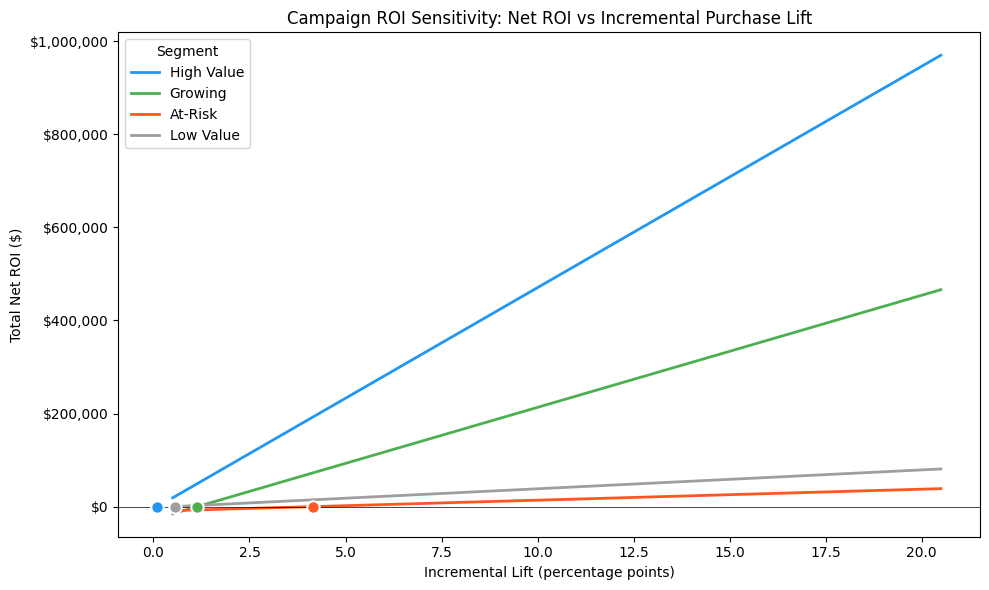

Dots mark break-even lift per segment. Any lift above the dot is profitable.
High Value's break-even dot is near 0% — almost any retention effort pays for itself.


In [27]:
# Sensitivity analysis: Net ROI across a range of incremental lifts
lift_range = np.arange(0.005, 0.21, 0.005)  # 0.5% to 20% incremental lift

fig, ax = plt.subplots(figsize=(10, 6))

colors_seg = {
    'High Value': '#2196F3',
    'Growing':    '#4CAF50',
    'At-Risk':    '#FF5722',
    'Low Value':  '#9E9E9E',
}

for seg in seg_order:
    if seg not in seg_profile.index:
        continue
    budget  = campaign_budgets[seg]['budget']
    avg_clv = seg_profile.loc[seg, 'avg_clv_12m']
    n_cust  = seg_profile.loc[seg, 'n_customers']

    # Net ROI per customer = lift × avg_clv − budget
    net_roi_per_cust = lift_range * avg_clv - budget
    total_net_roi = net_roi_per_cust * n_cust

    ax.plot(lift_range * 100, total_net_roi,
            color=colors_seg[seg], linewidth=2, label=seg)

    # Mark break-even point
    be_lift = budget / avg_clv
    ax.scatter(be_lift * 100, 0, color=colors_seg[seg],
               s=80, zorder=5, edgecolors='white', linewidths=1.5)

ax.axhline(y=0, color='black', linestyle='-', linewidth=0.5)
ax.set_xlabel('Incremental Lift (percentage points)')
ax.set_ylabel('Total Net ROI ($)')
ax.set_title('Campaign ROI Sensitivity: Net ROI vs Incremental Purchase Lift')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:,.0f}'))
ax.legend(title='Segment')
plt.tight_layout()
plt.show()

print("Dots mark break-even lift per segment. Any lift above the dot is profitable.")
print("High Value's break-even dot is near 0% — almost any retention effort pays for itself.")

### Interpreting the Sensitivity Analysis

**What the model provides vs. what requires experimentation:**

The CLV model gives us two things that don't require assumptions: (1) which customers are most valuable, and (2) their organic purchase probability. The one unknown — incremental campaign lift — is exactly what A/B testing measures.

**Key takeaways from the chart:**

- **High Value (blue)** has the steepest slope — each percentage point of lift generates more total ROI than any other segment because these customers have the highest CLV ($4,842). Combined with a 0.10% break-even threshold, this makes retention spend the single highest-ROI investment in the portfolio. The risk of *not* spending is asymmetric: losing even a few High Value customers costs more than the entire retention program budget.
- **Growing (green)** has the highest customer count, so even modest lifts scale into substantial total ROI. However, at $1,313 average CLV, the per-customer return per percentage point of lift is lower than High Value.
- **At-Risk (orange)** has the flattest slope and the highest break-even threshold (4.16%). This segment has the lowest average CLV ($240), which limits both the per-customer return and the margin for error. This is the segment where A/B test results matter most — if measured lift falls below ~4%, the campaign should be scaled back or redesigned.
- **Low Value (gray)** has a slightly steeper slope than At-Risk despite lower per-customer budgets, because its average CLV ($362) is 1.5× higher. The $2 email-only budget keeps break-even easily achievable (1 in 181), making this a low-risk, modest-return investment.

**Closing the loop:** When A/B test results come in, the assumed lift range gets replaced with measured lift. The sensitivity chart becomes a calibrated ROI forecast, and the pipeline transitions from planning tool to P&L tracker.

## 8. Save Final Outputs

In [28]:
os.makedirs('../data/processed', exist_ok=True)
df.to_csv('../data/processed/clv_final.csv', index=False)
print(f"Final CLV data saved to data/processed/clv_final.csv")
print(f"  Shape: {df.shape[0]:,} customers x {df.shape[1]} columns")
print(f"  Key columns: segment, clv_12m, p_purchase, spend_tier")

Final CLV data saved to data/processed/clv_final.csv
  Shape: 4,918 customers x 25 columns
  Key columns: segment, clv_12m, p_purchase, spend_tier


In [29]:
seg_order = ['High Value', 'Growing', 'At-Risk', 'Low Value']

print("=" * 55)
print("CLV PIPELINE COMPLETE")
print("=" * 55)
print(f"Total customers:      {len(df):,}")
print(f"Total predicted CLV:  ${df['clv_12m'].sum():,.0f}")
print(f"Median CLV:           ${df['clv_12m'].median():.2f}")
print()
for seg in seg_order:
    seg_data = df[df['segment'] == seg]
    if len(seg_data) > 0:
        n = len(seg_data)
        rev = seg_data['clv_12m'].sum()
        pct = rev / df['clv_12m'].sum() * 100
        print(f"  {seg:15s}: {n:,} customers | ${rev:>10,.0f} predicted ({pct:.1f}%)")
print("=" * 55)
print("\nOutput: data/processed/clv_final.csv")
print("Dashboard: streamlit run src/app.py")

CLV PIPELINE COMPLETE
Total customers:      4,918
Total predicted CLV:  $7,803,397
Median CLV:           $781.63

  High Value     : 982 customers | $ 4,754,448 predicted (60.9%)
  Growing        : 1,834 customers | $ 2,407,616 predicted (30.9%)
  At-Risk        : 982 customers | $   235,968 predicted (3.0%)
  Low Value      : 1,120 customers | $   405,365 predicted (5.2%)

Output: data/processed/clv_final.csv
Dashboard: streamlit run src/app.py


## Summary & Limitations

### What this pipeline delivers
1. **Stage 1** (`02_purchase_propensity_model.ipynb`): Calibrated LightGBM classifier assigns each customer a purchase probability. Brier score on the held-out test set is well below the naive baseline, and PR-AUC confirms strong discrimination. See notebook 02 Section 7 for exact metrics.
2. **Stage 2** (this notebook): `CLV = P(purchase) × E[revenue | tier]`, validated against a genuine 183-day holdout. See Section 5e for the revenue calibration ratio.
3. **Segmentation**: 4 tiers with differentiated budgets direct marketing spend toward customers with the highest expected return.
4. **Experiment-ready ROI framework**: Break-even incremental lifts quantified per segment, ready to plug in A/B test results.

### Known limitations
- **Dataset age:** Transactions from 2009–2011. Consumer behavior patterns may not generalize to current markets.
- **Geography:** Predominantly UK-based with some international orders — model is not calibrated for other markets.
- **Revenue tiers use historical monetary value:** Customers who shift spending level over time will land in the wrong tier.
- **Linear annualization:** 12-month CLV assumes the 183-day purchase rate holds for a full year, which ignores seasonality.
- **No promotional data:** Campaigns that change purchasing behavior aren't captured — the model measures organic propensity, not response to treatment. The campaign ROI section uses sensitivity analysis rather than assumed conversion rates for this reason.
- **B2B contamination:** Bulk orders (likely wholesale/B2B buyers) inflate high-end revenue tiers; separating B2C from B2B records would improve precision.

### Next steps for production
- Retrain monthly with a rolling observation window
- Replace spend tiers with a regression model as the dataset grows (>10K buyers)
- Incorporate product category, session engagement, and promotional history as features
- A/B test campaign budgets per segment to measure true incremental lift and close the feedback loop